# 03 - Borrower Segmentation

## Theory
Segmentation groups borrowers by behavior and exposure patterns to enable differentiated collection strategy.

## Algorithms compared
1. K-Means
2. MiniBatch K-Means
3. Hierarchical Clustering
4. Gaussian Mixture Models
5. DBSCAN

## Evaluation metrics
- Silhouette Score (higher better)
- Davies-Bouldin Index (lower better)
- Calinski-Harabasz Index (higher better)


## Definition
Segmentation groups borrowers into actionable cohorts for differentiated recovery treatment.

## Theory
This section explains the statistical or ML theory behind the technique and why it is useful in credit recovery operations.

## Mathematical Intuition
We translate the idea into score/probability/ranking logic so each metric can be interpreted quantitatively.

## Financial Intuition
We connect the method to borrower affordability, delinquency severity, collateral protection, and expected recoverable cashflows.

## Business Impact
We explain what this enables for collection managers, risk teams, and executives.

## Real-World Example
A Legal Escalation Candidate segment can be routed to legal preparation while Recovery Friendly gets lighter outreach.

## Visual Explanation
Charts in this notebook show how model/segment behavior changes across borrower groups.

## Code Explanation
Every code cell below is paired with interpretation so beginners can connect implementation details to business outcomes.

## Interpretation of Results
We summarize what changed, why it matters, and how to act on it.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.loan_recovery import (
    DATA_PATH,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    REPORTS_DIR,
    LoanDataLoader,
    FeatureEngineer,
    LoanEDA,
    BorrowerSegmenter,
    ModelTrainer,
    ModelEvaluator,
    RecoveryStrategyEngine,
    ModelExplainer,
    DashboardBuilder,
    LazyPredictBenchmark,
    PyCaretWorkflow,
    FLAMLOptimizer,
    SmartLoanRecoveryPipeline,
    load_model,
)

sns.set_theme(style="whitegrid")


In [2]:
def ensure_pipeline_artifacts() -> None:
    required = [
        TABLES_DIR / "manual_model_leaderboard.csv",
        TABLES_DIR / "feature_enriched_data.csv",
        MODELS_DIR / "best_manual_model.joblib",
    ]
    if not all(path.exists() for path in required):
        pipeline = SmartLoanRecoveryPipeline(data_path=DATA_PATH, random_state=42)
        pipeline.run()

ensure_pipeline_artifacts()


In [3]:
enriched = pd.read_csv(TABLES_DIR / "feature_enriched_data.csv")
segmenter = BorrowerSegmenter(random_state=42)
seg_out = segmenter.run(enriched)

display(seg_out.metrics_table)
display(seg_out.profile_table)
seg_out.named_segments


,algorithm,params,n_clusters,silhouette_score,davies_bouldin,calinski_harabasz,noise_ratio,stability_score
0,KMeans,"{'n_clusters': 3, 'n_init': 30}",3,0.9416,0.1181,1566.16,0.000,1.0000
1,Hierarchical,"{'n_clusters': 3, 'linkage': 'ward'}",3,0.9416,0.1181,1566.16,0.000,1.0000
2,GMM,"{'n_components': 3, 'covariance_type': 'full'}",3,0.8849,0.5539,1027.32,0.000,0.7266
3,MiniBatchKMeans,"{'n_clusters': 3, 'batch_size': 64}",3,0.6888,0.7870,835.47,0.000,0.2035
4,DBSCAN,"{'eps': 0.8, 'min_samples': 5}",2,0.3745,0.9077,11.20,0.974,1.0000


,segment,Monthly_Income,Loan_to_Income_Ratio,Debt_Burden_Score,Collateral_Coverage_Ratio,Missed_Payment_Severity,Delinquency_Score,Recovery_Difficulty_Index,Collection_Intensity_Score,Behavioral_Risk_Score,segment_size
0,0,8515.711111,0.341489,0.327518,4.906628,2.086595,0.654052,0.527349,0.053538,0.677751,495
1,1,10647.000000,0.316537,0.256729,670.328358,4.098472,0.568222,0.322624,0.128713,0.685000,1
2,2,10330.250000,0.151127,0.284294,279.978240,1.248301,0.652681,0.444334,0.026492,0.714167,4


{0: 'Legal Escalation Candidate Segment',
 1: 'High Income Low Risk Segment',
 2: 'Recovery Friendly Segment'}

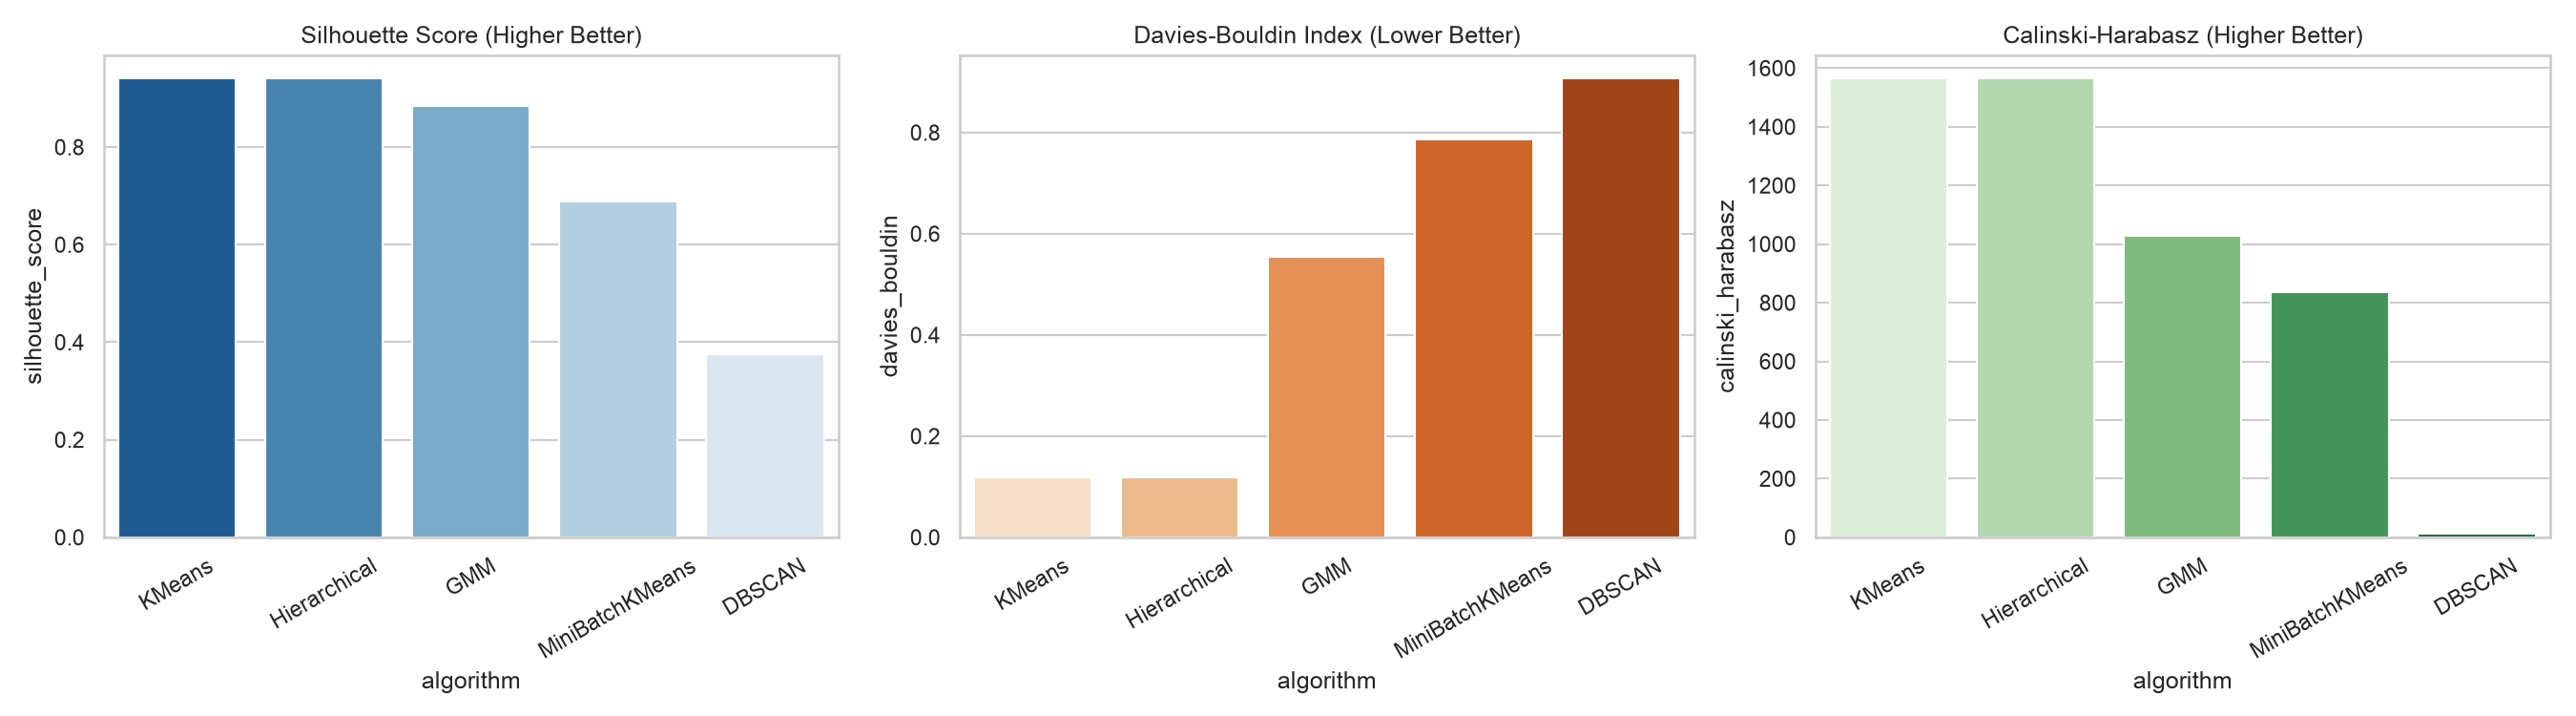

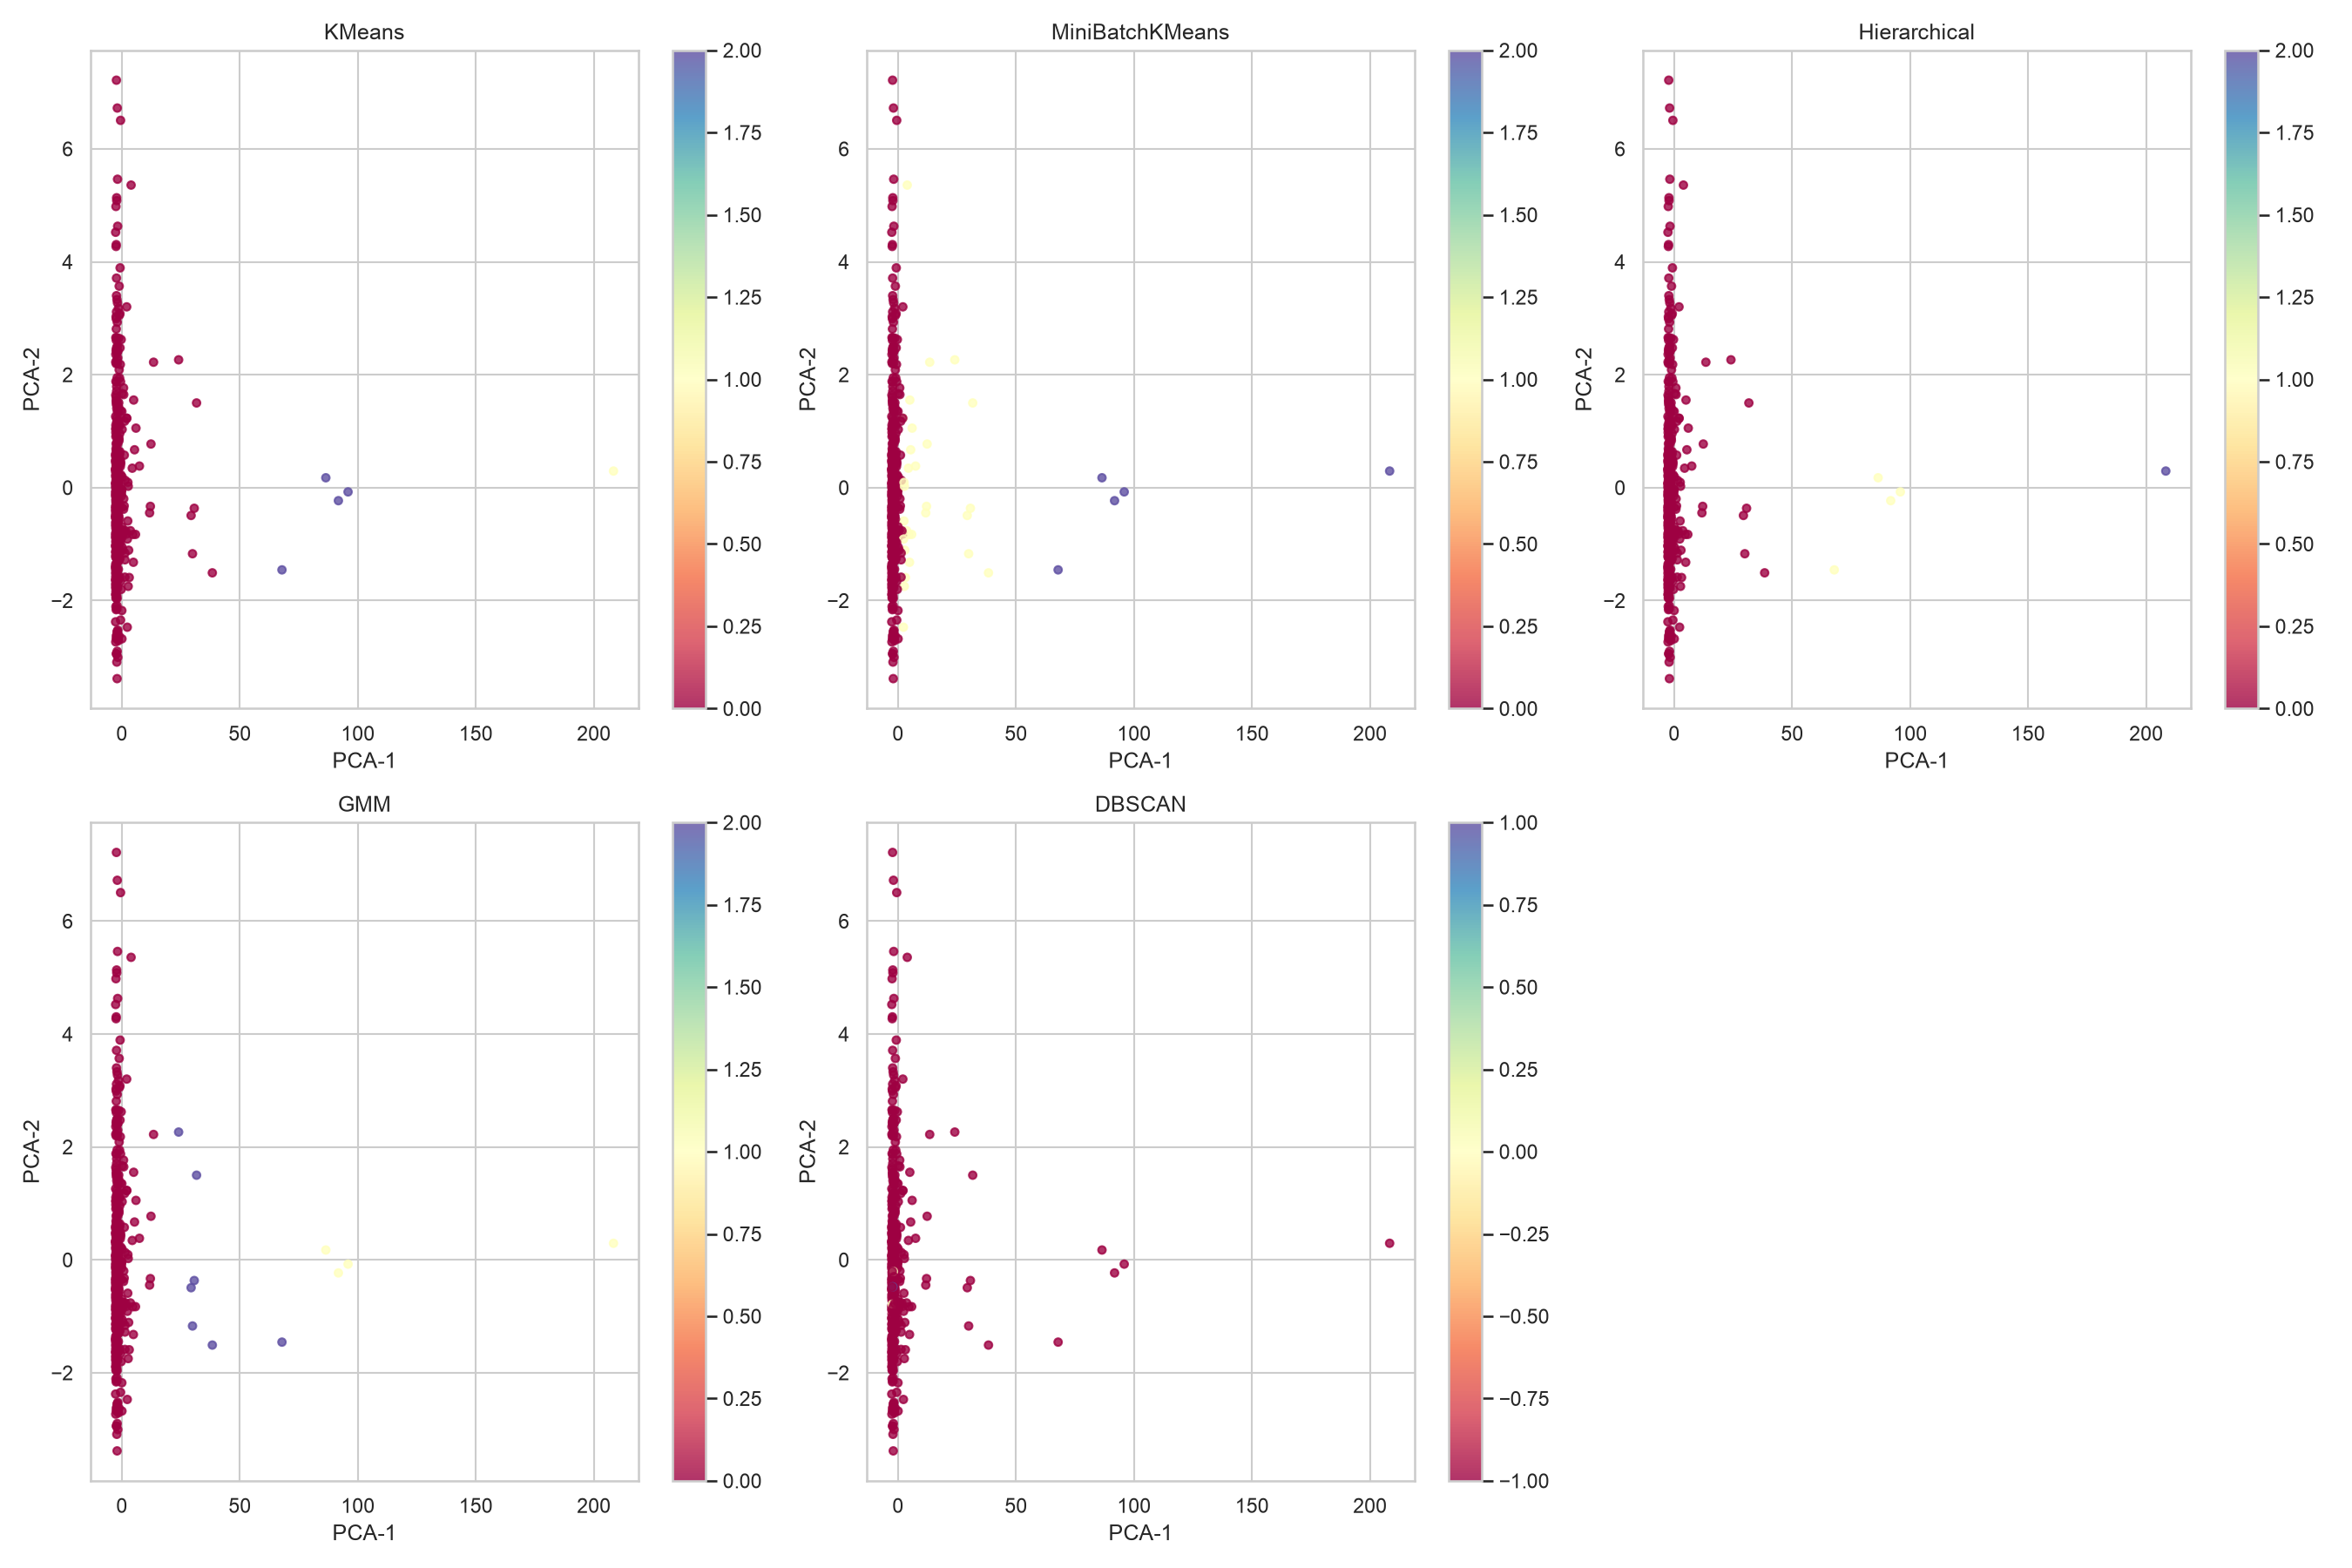

In [4]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES_DIR / "segmentation_metrics.png")))
display(Image(filename=str(FIGURES_DIR / "segmentation_pca.png")))


## Business Interpretation
Segment names are automatically generated from profile patterns (income, risk, burden, recoverability) so collections teams can act immediately.
